In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# 1. Load and Preprocess the dataset
# FIX: Added sep='\t' and names=['label', 'text'] because the file is tab-separated and has no header
df = pd.read_csv("data/spamhamdata.csv", sep='\t', names=['label', 'text'])

# Check for null values
print("--- Null Value Check ---")
print(df.isnull().sum())

# Check for duplicates
# 1.1. Check duplicates initially
initial_dupes = df.duplicated(subset=['text']).sum()
print(f"Duplicates before cleaning: {initial_dupes}")

# 1.2. Remove duplicates
df = df.drop_duplicates(subset=['text'], keep='first')

# 1.3. VERIFY: Check duplicates again (Should be 0)
final_dupes = df.duplicated(subset=['text']).sum()
print(f"Duplicates after cleaning: {final_dupes}")
print(f"Total unique emails remaining: {len(df)}")

# 1.4. Map string labels 'ham'/'spam' to numbers 0 and 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X_texts = df['text']
y = df['label_num']

--- Null Value Check ---
label    0
text     0
dtype: int64
Duplicates before cleaning: 403
Duplicates after cleaning: 0
Total unique emails remaining: 5169


In [3]:
# 2. Split with Stratification
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_texts, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [4]:
# 3. Vectorize (Bag of Words)
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

In [5]:
# 4. Train the Naive Bayes Classifier
model = MultinomialNB(alpha=0.1)
model.fit(X_train, y_train)

MultinomialNB(alpha=0.1)

In [6]:
# 5. Evaluate the results
y_pred = model.predict(X_test)
print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


Model Accuracy: 98.16%

Detailed Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       903
        Spam       0.94      0.92      0.93       131

    accuracy                           0.98      1034
   macro avg       0.96      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [7]:
# 6. Test with your specific 'fake' Retail Phishing emails
fake_emails = [
    "URGENT: Your retail invoice for $500 is overdue. Pay now.",
    "Congratulations! You've won a $1000 Walmart gift card! Click here.",
    "Verify your Amazon account password immediately to avoid suspension.",
    "Please find the attached report regarding the energy meeting tomorrow.",
    "Hey, are we still playing badminton this weekend at the college court?",
    "Verify Your Email Address Thanks for verifying your lmno2005@gmail.com email address for your CompTIA account! Your code is: 27909 Sincerely,CompTIA",
    "By completing the required activities, you have acquired:Badge 3 Day Streak Ownership of this badge is automatic and non-transferable. Side effects may include confidence and the desire to earn another one.No response expected or monitored. Keep on keeping on! ",
    "Hello and welcome,Your application for our Adobe certification and project internship has been moved to the shortlist for the next phase. We look forward to the possibility of you joining our upcoming cohort.Through this internship, you will have the chance to earn industry certifications and create a portfolio that reflects your hands-on experience. These verified skills are essential for showing employers exactly what you can achieve with digital tools.Please complete your registration by visiting the personalized portal link below. This will confirm your interest and allow us to process your final application details.Complete your application via this link: https://forms.gle/MS9zb7LgJcNSincerely yours,Program Director, Digital Skills Internship "
]

X_fake = vectorizer.transform(fake_emails)
predictions = model.predict(X_fake) 
probs = model.predict_proba(X_fake) # for probability instead of a direct 'spam' 'ham'

print("\n--- Manual Retail Test Results with Confidence ---")
for i, email in enumerate(fake_emails):
    pred = predictions[i]
    confidence = probs[i][pred] * 100 #converts probability into percentage
    label = "🚨 SPAM" if pred == 1 else "✅ HAM"
    print(f"[{label}] ({confidence:.2f}% confidence) -> {email}")


--- Manual Retail Test Results with Confidence ---
[🚨 SPAM] (98.14% confidence) -> URGENT: Your retail invoice for $500 is overdue. Pay now.
[🚨 SPAM] (100.00% confidence) -> Congratulations! You've won a $1000 Walmart gift card! Click here.
[🚨 SPAM] (77.82% confidence) -> Verify your Amazon account password immediately to avoid suspension.
[✅ HAM] (99.93% confidence) -> Please find the attached report regarding the energy meeting tomorrow.
[✅ HAM] (99.94% confidence) -> Hey, are we still playing badminton this weekend at the college court?
[🚨 SPAM] (98.84% confidence) -> Verify Your Email Address Thanks for verifying your lmno2005@gmail.com email address for your CompTIA account! Your code is: 27909 Sincerely,CompTIA
[✅ HAM] (99.83% confidence) -> By completing the required activities, you have acquired:Badge 3 Day Streak Ownership of this badge is automatic and non-transferable. Side effects may include confidence and the desire to earn another one.No response expected or monitored. 

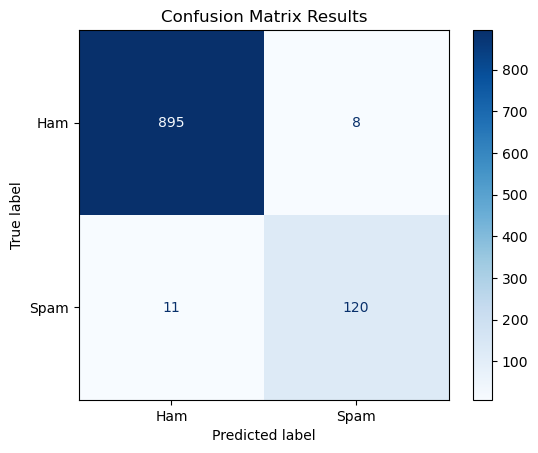

In [8]:
# 7. Plotting
# This line calculates the matrix AND draws the plot
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Ham', 'Spam'], cmap='Blues')

plt.title("Confusion Matrix Results") #Adds title
plt.savefig("confusion_matrix.png") # Saves the image 
plt.show()  # add this line

In [9]:
# 8. GUI
import gradio as gr

def predict_email(email_text):
    X = vectorizer.transform([email_text])
    pred = model.predict(X)[0]
    prob = model.predict_proba(X)[0]
    confidence = prob[pred] * 100
    label = "🚨 SPAM" if pred == 1 else "✅ HAM"
    return f"{label} — {confidence:.2f}% confidence"

demo = gr.Interface(
    fn=predict_email,
    inputs=gr.Textbox(lines=5, placeholder="Paste email here..."),
    outputs="text",
    title="Retail Phishing Detector",
    description="Enter an email to check if it's spam or legitimate."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [25]:
# 9. View Flagged Emails
import pandas as pd
import os

flagged_path = "/Users/aishahsyed/.gradio/flagged/dataset1.csv"

if os.path.exists(flagged_path):
    flagged = pd.read_csv(flagged_path)
    print("--- Flagged Emails Log ---")
    print(f"Total flagged emails: {len(flagged)}")
    print()
    print(flagged.to_string())
else:
    print("No flagged emails yet. Click the Flag button in the GUI to log an incorrect prediction.")

--- Flagged Emails Log ---
Total flagged emails: 4

                                                                                                                                             email_text                       output                   timestamp
0                            "Your account has been suspended, verify now"\n"You've won a prize, click here"\n"Urgent invoice overdue, pay immediately"  🚨 SPAM — 100.00% confidence  2026-04-20 11:08:04.949392
1  Verify Your Email Address Thanks for verifying your lmno2005@gmail.com email address for your CompTIA account! Your code is: 27909 Sincerely,CompTIA   🚨 SPAM — 98.84% confidence  2026-04-25 12:07:10.780076
2  Verify Your Email Address Thanks for verifying your lmno2005@gmail.com email address for your CompTIA account! Your code is: 27909 Sincerely,CompTIA   🚨 SPAM — 98.84% confidence  2026-04-25 12:07:19.590175
3  Verify Your Email Address Thanks for verifying your lmno2005@gmail.com email address for your CompTIA account